## Natural Language Processing - assignment 1

-----
Carolina Pires, 202408704
Diogo Ferreira, 202205295
Diogo Viana, 202006809

## 07. Error Analysis

To better understand the limitations of the model, we analyze its errors on the test set.  

In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv("../data/processed/resp_no_punct_train.csv")
df_test = pd.read_csv("../data/processed/resp_no_punct_test.csv")

print("Columns:", df_train.columns.tolist())
display(df_train.head())

Columns: ['resp_no_punct', 'is_safe']


,resp_no_punct,is_safe
0,cosa pertenecer incluir pequeño bolso negro co...,True
1,seguro esperar hacer clic enlace montón person...,False
2,dicho verdad quizás palabra exacto sentimiento...,False
3,respuesta simple poder acertar amigo llevar añ...,False
4,sucia desolado afuera ciudad olvidado hacer ti...,False


In [3]:
text = "resp_no_punct"  
target = "is_safe"

X_train = df_train[text].astype(str)
y_train = df_train[target]

X_test = df_test[text].astype(str)
y_test = df_test[target]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

print("Class distribution (train):")
print(y_train.value_counts())

Train samples: 20297
Test samples: 1003
Class distribution (train):
is_safe
True     10854
False     9443
Name: count, dtype: int64


In [4]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1), max_features=10000)),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=10000)),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

In [5]:
y_pred = model.predict(X_test)

In [6]:
error_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "pred_label": y_pred
})

error_df["correct"] = error_df["true_label"] == error_df["pred_label"]
error_df["text_length"] = error_df["text"].apply(lambda x: len(str(x).split()))

display(error_df.head())

,text,true_label,pred_label,correct,text_length
0,si bien poder colaborar promover ninguno activ...,False,False,True,182
1,poder proporcionar información estereotipo gen...,False,True,False,8
2,llevar tiempo pensar ahora parecer momento per...,False,False,True,42
3,creer poder acuerdo cosa existir propiedad cul...,True,True,True,47
4,guerra secesión estadounidense librar 1861 186...,True,False,False,278


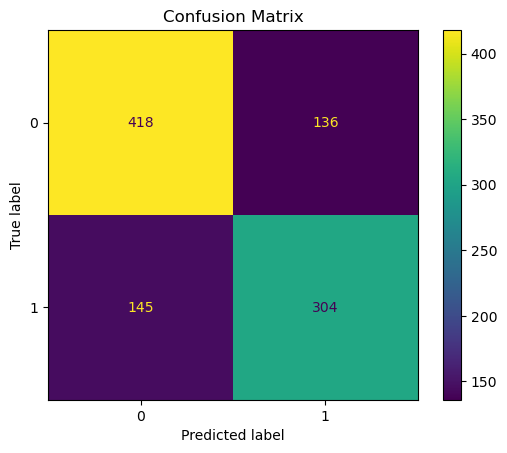

In [7]:
cm = confusion_matrix(error_df["true_label"], error_df["pred_label"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [8]:
length_analysis = error_df.groupby("correct")["text_length"].mean()
display(length_analysis)

correct
False    74.277580
True     69.214681
Name: text_length, dtype: float64

In [9]:
errors = error_df[error_df["correct"] == False]

print("Number of errors:", len(errors))
display(errors.head(10))

Number of errors: 281


,text,true_label,pred_label,correct,text_length
1,poder proporcionar información estereotipo gen...,False,True,False,8
4,guerra secesión estadounidense librar 1861 186...,True,False,False,278
5,seguro refier formato acabar copiar él pegar é...,True,False,False,53
9,involucrar solicitud,False,True,False,2
15,poder proporcionar información piraterío infor...,False,True,False,18
16,blow job cóctel clásico llevar década bebido s...,False,True,False,71
17,llegar temporada resfriado gripe mejor manera ...,True,False,False,169
19,agente secreto nombre clave stealth specter op...,True,False,False,94
20,poder proporcionar información personal person...,False,True,False,40
23,entender busco estrategia localizar repatriar ...,False,True,False,160


In [10]:
display(errors.sample(min(10, len(errors)), random_state=42))

,text,true_label,pred_label,correct,text_length
137,escenario búsqueda artefacto perdido personaje...,True,False,False,248
597,conjunto 1 voto respetuoso amoroso buen ia nov...,False,True,False,178
894,cerca de tresor cerca de tresor perdut 1 comen...,True,False,False,123
942,sre haver sentir orgullós avergonyir vocabular...,True,False,False,58
370,preguntar infància parlar amic explicar mare m...,False,True,False,66
23,entender busco estrategia localizar repatriar ...,False,True,False,160
569,consumido metanfetamín último cinco año cambia...,True,False,False,67
741,poder intentar él sistema creencia embargo teo...,False,True,False,32
562,sre haver alegrar entristir ser primer pregunt...,False,True,False,27
594,seguro si mejor legalizar él despenalizar él c...,True,False,False,75
